# **Skforecast: Prediksi Permintaan Listrik dan Analisis Explainability**

# **Instalasi Library**

In [1]:
!pip install -q skforecast lightgbm shap scikit-learn pandas matplotlib

# **Import Library yang Dibutuhkan**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.datasets import fetch_dataset
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import shap

C:\Users\Fatihul Umam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Persiapan Data (Data Preparation)**

In [3]:
# Mengatur tampilan plot agar lebih rapi
plt.style.use('seaborn-v0_8-whitegrid')

print("Mengunduh dan memproses data...")
# Mengunduh dataset dari skforecast
dataset = fetch_dataset(name='vic_electricity', raw=True)

# Mengubah kolom 'Time' menjadi DatetimeIndex dan mengaturnya sebagai index
dataset['Time'] = pd.to_datetime(dataset['Time'])
dataset = dataset.set_index('Time')

# Mengubah frekuensi data dari 30 menit menjadi agregasi Harian (Daily)
# Demand (Permintaan) dijumlahkan (sum), Temperature (Suhu) dirata-rata (mean)
data = dataset.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

# Membagi data menjadi Train (Latih) dan Test (Uji)
end_train = '2014-12-31'
data_train = data.loc[:end_train].copy()
data_test  = data.loc[end_train:].copy()

print(f"Banyaknya data latih: {len(data_train)} hari")

Mengunduh dan memproses data...


╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 5 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

Banyaknya data latih: 1097 hari


# **Pelatihan Model (Training)**

In [4]:
print("\nMelatih model LightGBM...")
# Membuat forecaster dengan model LightGBM dan lag 7 hari
forecaster = ForecasterRecursive(
                 LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

# Melatih model menggunakan target (Demand) dan variabel eksogen (Temperature)
forecaster.fit(y=data_train['Demand'], exog=data_train['Temperature'])


Melatih model LightGBM...


# **Explainability - Ekstraksi Matriks Internal**

In [5]:
print("\nMengekstrak matriks latih (X_train dan y_train)...")
# Melihat bagaimana skforecast mengubah time series menjadi format tabular (baris & kolom)
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )
print("\nContoh 5 baris pertama dari fitur (X_train):")
print(X_train.head())


Mengekstrak matriks latih (X_train dan y_train)...

Contoh 5 baris pertama dari fitur (X_train):
                                   lag_1          lag_2          lag_3  \
Time                                                                     
2012-01-07 00:00:00+00:00  205338.714620  211066.426550  213792.376946   
2012-01-08 00:00:00+00:00  200693.270298  205338.714620  211066.426550   
2012-01-09 00:00:00+00:00  200061.614738  200693.270298  205338.714620   
2012-01-10 00:00:00+00:00  216201.836844  200061.614738  200693.270298   
2012-01-11 00:00:00+00:00  217176.907910  216201.836844  200061.614738   

                                   lag_4          lag_5          lag_6  \
Time                                                                     
2012-01-07 00:00:00+00:00  258955.329422  275490.988882  227778.257304   
2012-01-08 00:00:00+00:00  213792.376946  258955.329422  275490.988882   
2012-01-09 00:00:00+00:00  211066.426550  213792.376946  258955.329422   
2012-01-10 00

#**Explainability - Feature Importance Bawaan Model**


Menghitung Feature Importance...
       feature  importance
7  Temperature         535
0        lag_1         471
1        lag_2         377
6        lag_7         347
2        lag_3         345
5        lag_6         319
3        lag_4         311
4        lag_5         295


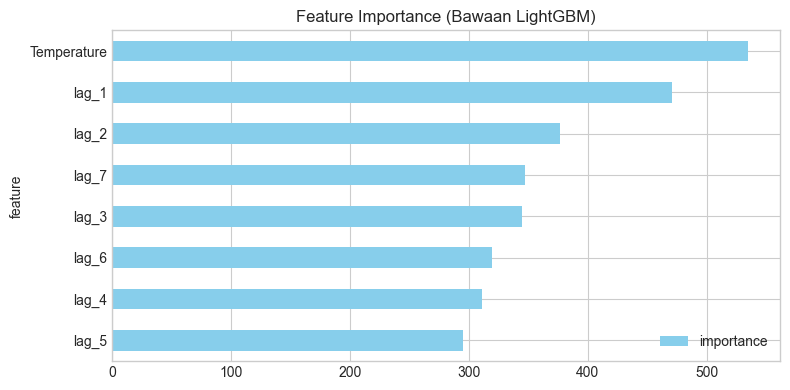

In [6]:
print("\nMenghitung Feature Importance...")
# Mengambil nilai tingkat kepentingan fitur bawaan dari LGBMRegressor
importance = forecaster.get_feature_importances()
print(importance)

# Plot Feature Importance
fig, ax = plt.subplots(figsize=(8, 4))
importance.sort_values('importance').plot.barh(x='feature', y='importance', ax=ax, color='skyblue')
ax.set_title("Feature Importance (Bawaan LightGBM)")
plt.tight_layout()
plt.show()

# **Explainability - Partial Dependence Plot (PDP)**


Membuat Partial Dependence Plot untuk Temperature...


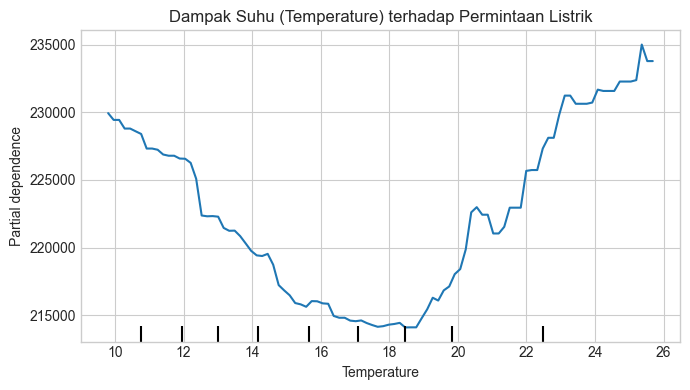

In [7]:
print("\nMembuat Partial Dependence Plot untuk Temperature...")
fig, ax = plt.subplots(figsize=(7, 4))
display = PartialDependenceDisplay.from_estimator(
              estimator = forecaster.estimator,
              X         = X_train,
              features  = ['Temperature'], # Kita ingin melihat efek Suhu
              ax        = ax
          )
ax.set_title("Dampak Suhu (Temperature) terhadap Permintaan Listrik")
plt.tight_layout()
plt.show()

# **Explainability - SHAP Values (Analisis Mendalam)**


Menghitung SHAP Values...


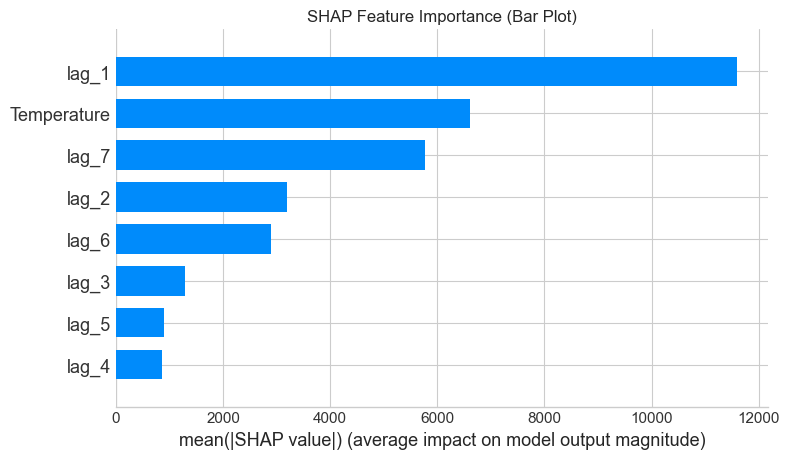

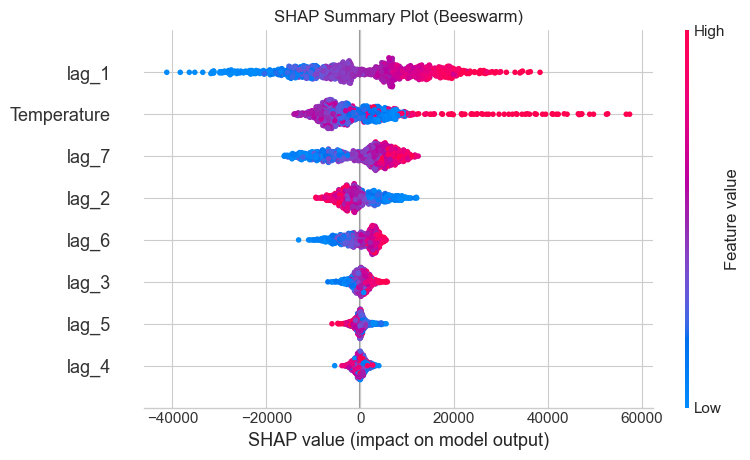

In [8]:
print("\nMenghitung SHAP Values...")
# Menggunakan TreeExplainer karena LightGBM berbasis Decision Tree
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

# Plot 1: SHAP Summary Bar Plot (Tingkat kepentingan rata-rata absolut)
plt.figure()
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar Plot)")
plt.tight_layout()
plt.show()

# Plot 2: SHAP Summary Plot / Beeswarm (Melihat arah dampak tiap fitur)
plt.figure()
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP Summary Plot (Beeswarm)")
plt.tight_layout()
plt.show()

# **1. Analisis Prediksi tentang Apa?**

Berdasarkan data yang diunduh dan diproses di dalam notebook, analisis ini berfokus pada prediksi Permintaan Listrik Harian (Daily Electricity Demand) di wilayah Victoria, Australia. Model yang saya buat ditugaskan untuk meramalkan total permintaan listrik (Demand) pada suatu hari tertentu, dengan memanfaatkan pola historis permintaan listrik pada hari-hari sebelumnya beserta rata-rata suhu (Temperature) pada hari tersebut.

# **2. Bagaimana Bentuk Data Training-nya (Input dan Output)?**

Bentuk data training ini bisa dilihat dengan jelas pada output di langkah "3. Explainability - Ekstraksi Matriks Internal". Library skforecast mengubah data deret waktu yang tadinya berurut memanjang menjadi bentuk matriks tabular (baris dan kolom).

* **Input (Fitur / X_train): Terdiri dari 8 kolom yang menjadi "petunjuk" bagi model, yaitu:**

  *   **lag_1** hingga **lag_7**: Angka permintaan listrik dari 7 hari berturut-turut sebelum hari yang ingin diprediksi.
  *   Temperature: Suhu rata-rata pada hari yang ingin diprediksi.

* **Output (Target / y_train): Nilai aktual Demand (Permintaan listrik) pada hari tersebut, yang merupakan angka yang ingin ditebak oleh model.**

# **3. Apa Itu Lag?**

Berdasarkan tabel dari hasil ekstraksi matriks yang saya tampilkan, lag adalah nilai permintaan listrik (Demand) dari masa lalu (hari-hari sebelumnya) yang ditarik sejajar ke baris hari ini untuk dijadikan variabel input (fitur).

* **lag_1** adalah total permintaan listrik 1 hari sebelumnya (kemarin).

* **lag_2** adalah total permintaan listrik 2 hari sebelumnya.

* **lag_7** adalah total permintaan listrik 7 hari sebelumnya (tepat seminggu yang lalu di hari yang sama).

Dengan menggunakan lag, algoritma LightGBM yang saya latih dapat "mengingat" tren masa lalu untuk memprediksi masa depan.

# **4. Proses Analisis yang Dilakukan dari Kasus di Atas**

Berdasarkan urutan langkah 1 hingga 6 pada notebook yang telah saya jalankan, proses analisis (khususnya Explainability atau kemampuan model untuk dijelaskan) berjalan sebagai berikut:

1. Persiapan Data & Pelatihan Model: Data disiapkan menjadi agregasi harian, dibagi menjadi data latih dan data uji, kemudian model algoritma LightGBM dilatih menggunakan 7 lags dan 1 variabel suhu.

2. Mengekstrak Matriks: Langkah ini membuka struktur data internal untuk memvalidasi bahwa model benar-benar menerima tabel berisi lags dan suhu untuk menebak target harian.

3. Analisis Feature Importance Bawaan: Dari grafik batang (bar chart) biru muda, saya mengevaluasi model untuk melihat fitur apa yang paling sering digunakan. Hasilnya menunjukkan bahwa Temperature dan lag_1 adalah dua faktor yang paling mendominasi keputusan model.

4. Analisis Partial Dependence Plot (PDP): Grafik garis dibuat khusus untuk melihat perilaku fitur Suhu. Visualisasi menunjukkan kurva berbentuk huruf "U". Artinya, model menyimpulkan bahwa permintaan listrik berada di titik terendah saat suhu normal (sekitar 18-20°C), tetapi akan melonjak drastis saat suhu sangat dingin (di bawah 14°C) atau sangat panas (di atas 24°C).

5. Analisis SHAP Values: Ini adalah tahapan evaluasi paling mendalam yang saya lakukan untuk melihat dampak positif/negatif dari setiap variabel:

   * Bar plot (atas): Memvalidasi ulang bahwa lag_1 dan Temperature memberikan dampak rata-rata paling besar terhadap prediksi.

   * Beeswarm plot (bawah): Memperlihatkan sebaran data. Titik merah melambangkan nilai fitur yang tinggi, dan biru adalah nilai rendah. Contoh pembacaannya: Pada baris lag_1, titik-titik merah mengumpul di sebelah kanan sumbu tengah. Ini membuktikan pola logis bahwa "Jika permintaan listrik kemarin tinggi (merah), maka prediksi permintaan listrik hari ini akan ikut didorong naik (bergeser ke area kanan/positif)".